Load Packages and settings

In [19]:
from sklearn.metrics import r2_score
from scipy.stats import gaussian_kde 
from mpl_toolkits.axes_grid1 import make_axes_locatable
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.axes_grid1.inset_locator import inset_axes
from sklearn.metrics import r2_score
import xarray as xr

#select particular representative gauge
reg = 'CT'

if reg == 'CT':
    columnname = str(54)
    mask_size = '892'
elif reg == 'SR':
    columnname = str(38)
    mask_size = '961'

MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 
SimDir = "/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/simu/"

# list_size = ['892','1658','3454','7071']  
# mask_size = list_size[0]
# train_size = list_size[1]

Sample based on event information from INGV catalog

In [20]:
#select particular representative gauge
reg = 'CT'

if reg == 'SR':
    columnname = str(54)
elif reg == 'CT':
    columnname = str(38)

#read combined dataframe
combined = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/info/sampling_input_{reg}_{columnname}.csv')

# far = combined.groupby('event_type').get_group(1)
# near = combined.groupby('event_type').get_group(0)
MLDir = '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami' 

Read SIS sample from Alice

In [17]:
list_size = ['1500','3000','6000']  
file_path = f'{MLDir}/data/simu/tempINGV/scenarios_SIH_unique_{reg}_{list_size[1]}.txt'
sample_list = pd.read_csv(file_path)
sample_list = sample_list.sample(frac=1).reset_index(drop=True)
sample = combined[combined['eve_id'].isin(sample_list['Sampled_Scenarios'])]
print('Unique sampled events:',len(sample['id'].unique()))

Unique sampled events: 1896


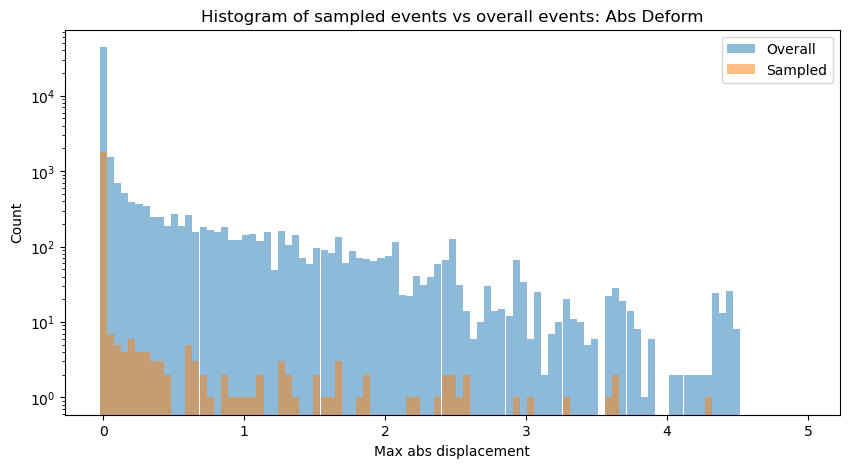

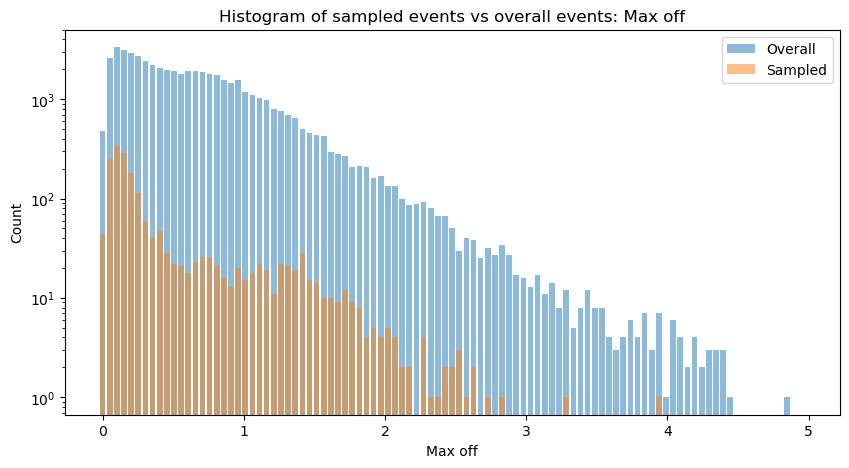

In [18]:
bin_splits = 100
start = 0
stop = 5
bin_def =  np.linspace(start,stop,bin_splits)

#plot histogram of sampled events vs overall events using bin_def for deform
overall_hist, overall_bins = np.histogram(combined['max_absdz'], bins=bin_def)
sample_hist, sample_bins = np.histogram(sample['max_absdz'], bins=bin_def)

# Plot histograms
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(overall_bins[:-1], overall_hist,width=0.05,alpha=0.5, label='Overall')
ax.bar(sample_bins[:-1], sample_hist, width=0.05, alpha=0.5, label='Sampled')
ax.set(xlabel='Max abs displacement', ylabel='Count')
ax.set_yscale('log')
plt.title('Histogram of sampled events vs overall events: Abs Deform')
plt.legend()
plt.show()

#plot histogram of sampled events vs overall events using bin_def
overall_hist, overall_bins = np.histogram(combined['max_off'], bins=bin_def)
sample_hist, sample_bins = np.histogram(sample['max_off'], bins=bin_def)

# Plot histograms
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(overall_bins[:-1], overall_hist,width=0.04,alpha=0.5, label='Overall')
ax.bar(sample_bins[:-1], sample_hist, width=0.04, alpha=0.5, label='Sampled')
ax.set(xlabel='Max off', ylabel='Count')
ax.set_yscale('log')
plt.title('Histogram of sampled events vs overall events: Max off')
plt.legend()
plt.show()


In [23]:
size_list = ['1500']
reg_list = ['CT']

total_unique_events = []

for reg in reg_list:
    for size in size_list:
        #filter events with lower than threshold of 0.1 at atleast one station
        offshore_threshold = 0.1
        onshore_threshold = 0.20
        split = 0.70

        #offshore
        allpts_max = np.loadtxt(f'{MLDir}/data/info/grid0_allpts87_alleve53550.offshore.txt', dtype='str',skiprows=1)

        #select particular representative gauge for files and gauges for threshold test
        if reg == 'CT':
            columnname = str(38)
            GaugeNo = list(range(35,44)) #for Catania
        elif reg == 'SR':
            GaugeNo = list(range(53,58)) #for Siracusa
            columnname = str(54)

        # event_list = np.loadtxt(f'{MLDir}/data/events/sample_events{size}_{reg}_{columnname}.txt', dtype='str') #for harcode
        event_list = sample['id'].unique()

        #find index of event list in allpts_max with duplicate events
        event_list_index = np.array([np.where(allpts_max[:,0]==event)[0] for event in event_list]).flatten()
        allpts_max = allpts_max[event_list_index]
        Gauge_Max = allpts_max[:,GaugeNo]
        maxPerEve = Gauge_Max.astype(float).max(axis=1)

        #onshore
        inun_info = np.loadtxt(f'{MLDir}/data/info/CHeight_{reg}_alleve53550.onshore.txt', dtype='str',skiprows=1)
        inun_info = inun_info[event_list_index]
        #get column of max inundation depth which is 3rd column
        Inun_Max = inun_info[:,2]

        #filter events greater than thresholds for gauge and min inundation depth
        offshore_check = maxPerEve > offshore_threshold
        onshore_check = Inun_Max.astype(float) > onshore_threshold
        print("check threshold of events, offshore and onshore")
        print(len(event_list), len(offshore_check), len(onshore_check))
        print("Count of offshore_check True values:", np.sum(offshore_check))
        print("Count of onshore_check True values:", np.sum(onshore_check))

        #combine event list with offshore and onshore max values and save
        event_maxlist = np.column_stack((event_list, maxPerEve, Inun_Max))
        # np.savetxt(f'{MLDir}/data/events/event_maxvaloffon_{reg}_{size}.txt', event_maxlist, fmt='%s')

        overall_check = offshore_check & onshore_check
        print("Count of overall_check True values:", np.sum(overall_check))
        event_list = event_list[overall_check]

        #pick unique events only
        event_list = np.unique(event_list)

        #append to total unique events and find new unique events
        total_unique_events = np.append(total_unique_events, event_list)
        total_unique_events = np.unique(total_unique_events)

        #shuffle events
        np.random.shuffle(event_list)

        #split events in train and test and validation as 75:25
        train_events = event_list[:int(len(event_list)*split)] 
        test_events = event_list[int(len(event_list)*split):]

        #print number of events in each set
        print('total events:',len(event_list),'train events:',len(train_events),'test events:',len(test_events))
        
        #save events in file
        np.savetxt(f'{MLDir}/data/events/shuffled_events_{reg}_{size}.txt', event_list, fmt='%s')
        np.savetxt(f'{MLDir}/data/events/train_events_{reg}_{size}.txt', train_events, fmt='%s')
        np.savetxt(f'{MLDir}/data/events/test_events_{reg}_{size}.txt', test_events, fmt='%s')

# #save total unique events as total train events
# np.savetxt(f'{MLDir}/data/info/train_events_{reg}_total.txt', total_unique_events, fmt='%s')



check threshold of events, offshore and onshore
1896 1896 1896
Count of offshore_check True values: 1800
Count of onshore_check True values: 1893
Count of overall_check True values: 1799
total events: 1799 train events: 1259 test events: 540


In [24]:
import folium
import pandas as pd
import numpy as np


# file_list = ['/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/events/shuffled_events_CT_762.txt',
# '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/events/shuffled_events_CT_1441.txt',
# '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/events/shuffled_events_CT_2589.txt',
# '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/events/shuffled_events_CT_4005.txt',
# '/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/events/shuffled_events_CT_6734.txt']

#read train events
# train_events = np.loadtxt(f'{MLDir}/data/info/train_events_{reg}_total.txt', dtype='str')
# train_events = np.loadtxt(f'{MLDir}/data/events/shuffled_events_CT_1658 .txt', dtype='str')

#Create location keyword
DF_eve = pd.read_csv(f'/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/data/info/sampling_input_{reg}_{columnname}.csv')

#event_list train events, pick form DF_eve
Train_eve = DF_eve[DF_eve['id'].isin(train_events)]

#Unique EQ locations overall
unique_locations = len(DF_eve['Location'].unique())
print('uniques EQ locations in the dataset:',unique_locations)

#filter 1 row per unique location from list of DF_eve
DF_eve_unique = DF_eve.drop_duplicates(subset=['Location'], keep='first')
#reset index
DF_eve_unique.reset_index(drop=True, inplace=True)

#unique locations for training events
unique_locations_train = len(Train_eve['Location'].unique())
print('uniques EQ locations in the training dataset:',unique_locations_train)

#filter 1 row per unique location from list of train list
Train_eve_unique = Train_eve.drop_duplicates(subset=['Location'], keep='first')
#reset index
Train_eve_unique.reset_index(drop=True, inplace=True)

data_pts = np.loadtxt('/mnt/beegfs/nragu/tsunami/ML4SicilyTsunami/resources/raw/pois_eastern_sicily_2km.txt', dtype=str)
id_pts = data_pts[:, 0]
lon_pts = data_pts[:, 1].astype(float)
lat_pts = data_pts[:, 2].astype(float)
z_pts = data_pts[:, 3].astype(float)

#Create a map with the unique locations
eve_map = folium.Map(location=[np.mean(DF_eve_unique['lat']),
                               np.mean(DF_eve_unique['lon'])],
                               zoom_start=7, tiles='OpenStreetMap')

# Basemaps
folium.TileLayer(tiles = 'https://server.arcgisonline.com/ArcGIS/rest/services/World_Imagery/MapServer/tile/{z}/{y}/{x}',
        attr = 'Esri',
        name = 'Esri Satellite',
        overlay = False,
        control = True,
        show = False).add_to(eve_map)

# Create a feature group for the offshore points and eq loc 
fg_pts = folium.FeatureGroup(name='Offshore Points Txt').add_to(eve_map)
fg_Unq_EQ = folium.FeatureGroup(name='Unique EQ Location').add_to(eve_map)
fg_Train_EQ = folium.FeatureGroup(name='Train EQ Location').add_to(eve_map)

for i in range(len(DF_eve_unique)-1):
    folium.CircleMarker([DF_eve_unique.loc[i+1,'lat'], DF_eve_unique.loc[i+1,'lon']],radius= 3,color = 'green',opacity=0.95 ).add_to(fg_Unq_EQ)
folium.LayerControl().add_to(eve_map)

for i in range(len(Train_eve_unique)-1):
    folium.CircleMarker([Train_eve_unique.loc[i+1,'lat'], Train_eve_unique.loc[i+1,'lon']],radius= 1,color = 'red',opacity=0.95 ).add_to(fg_Train_EQ)
folium.LayerControl().add_to(eve_map)

for id, lat, lon,z in zip(id_pts, lat_pts, lon_pts, z_pts):
    info = f"ID:{id}, Depth: {z} "  # Create tooltip string
    folium.CircleMarker(location=[lat, lon],
                  tooltip=info,radius=0.5,
                  icon=folium.Icon(color='blue', icon='')).add_to(fg_pts)
    


# # Save the map as an HTML file or plot here
# # eve_map.save('tsu_PS_eve_map.html')

eve_map


uniques EQ locations in the dataset: 1283
uniques EQ locations in the training dataset: 408


Add events from 4-8 m POI range

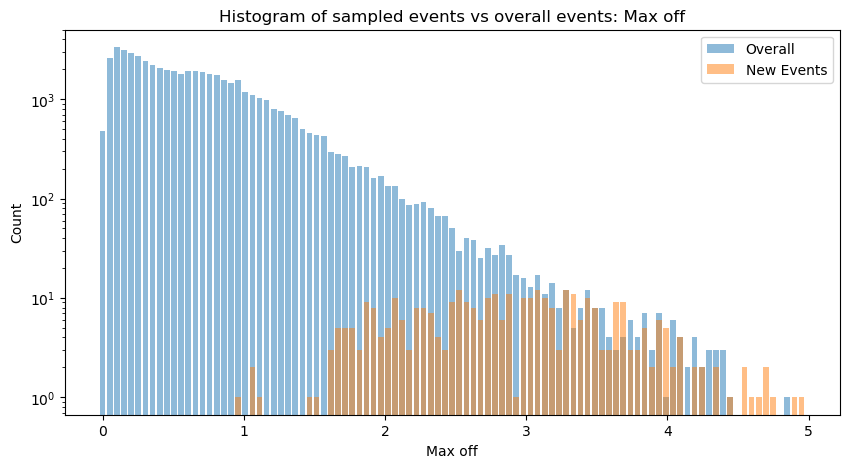

In [22]:
file_path = f'{MLDir}/data/simu/tempINGV/med09159_BS_not_simulated_MIH.txt'
sample_list = pd.read_csv(file_path,sep=' ',header=None)
sample_list.columns = ['Sampled_Scenarios','max_off','max_absdz']


bin_splits = 100
start = 0
stop = 5
bin_def =  np.linspace(start,stop,bin_splits)

#plot histogram of sampled events vs overall events using bin_def
overall_hist, overall_bins = np.histogram(combined['max_off'], bins=bin_def)
sample_hist, sample_bins = np.histogram(sample_list['max_off'], bins=bin_def)

# Plot histograms
fig, ax = plt.subplots(figsize=(10, 5))
ax.bar(overall_bins[:-1], overall_hist,width=0.04,alpha=0.5, label='Overall')
ax.bar(sample_bins[:-1], sample_hist, width=0.04, alpha=0.5, label='New Events')
ax.set(xlabel='Max off', ylabel='Count')
ax.set_yscale('log')
plt.title('Histogram of sampled events vs overall events: Max off')
plt.legend()
plt.show()

